# **Tugas Besar II4012 AI untuk Bisnis:**  AI Player Scouting

---  

![alt text](image.png)

Pada tugas ini, kami akan melakukan `JUDUL TUGAS DI PDF` dari `data apa` menggunakan *APA* 

Praktikum ini disusun oleh:
|Nama Lengkap|NIM
|:-|:-:|
|Ananda Fajrul Zidan|18223067|
|||
|||
|||

dan sumber data yang diuji adalah:  
- `SUMBER DATA.csv`

## **Inisiasi**  
---  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

### Impor Library
- **pandas**: Untuk manipulasi dan analisis data dalam format tabel (DataFrame)
- **matplotlib.pyplot**: Library untuk membuat visualisasi/grafik
- **glob**: Untuk mencari file dengan pola tertentu di direktori (contoh: `ea-sports-fc-*.csv`)
- **seaborn**: Library visualisasi yang dibangun di atas matplotlib untuk grafik yang lebih menarik

In [2]:
file_list = glob.glob('ea-sports-fc-*.csv')
df_list = []

for file in file_list:
    df_temp = pd.read_csv(file)
    df_list.append(df_temp)

df_master = pd.concat(df_list, ignore_index=True)
print(f"Total pemain yang terkumpul: {len(df_master)}")
df_master.to_csv('ea_fc_26_master_dataset.csv', index=False)

Total pemain yang terkumpul: 1000


### Membaca dan Menggabungkan Data CSV
- **glob.glob()**: Mencari semua file yang cocok dengan pola `ea-sports-fc-*.csv` (file dengan awalan "ea-sports-fc-" dan ekstensi .csv)
- **Loop for**: Membaca setiap file CSV satu per satu dan menyimpannya ke dalam list `df_list`
- **pd.concat()**: Menggabungkan semua DataFrame dalam list menjadi satu DataFrame besar (`df_master`)
- **ignore_index=True**: Mereset index agar tidak ada duplikasi nomor baris setelah penggabungan
- **to_csv()**: Menyimpan data gabungan ke file `ea_fc_26_master_dataset.csv` untuk backup

In [3]:
list(df_master.columns.values)

['id',
 'rank',
 'overallRating',
 'firstName',
 'lastName',
 'commonName',
 'birthdate',
 'height',
 'skillMoves',
 'weakFootAbility',
 'preferredFoot',
 'leagueName',
 'weight',
 'avatarUrl',
 'shieldUrl',
 'alternatePositions/0/id',
 'alternatePositions/0/label',
 'alternatePositions/0/shortLabel',
 'playerAbilities/0/id',
 'playerAbilities/0/label',
 'playerAbilities/0/description',
 'playerAbilities/0/imageUrl',
 'playerAbilities/0/type/id',
 'playerAbilities/0/type/label',
 'playerAbilities/1/id',
 'playerAbilities/1/label',
 'playerAbilities/1/description',
 'playerAbilities/1/imageUrl',
 'playerAbilities/1/type/id',
 'playerAbilities/1/type/label',
 'playerAbilities/2/id',
 'playerAbilities/2/label',
 'playerAbilities/2/description',
 'playerAbilities/2/imageUrl',
 'playerAbilities/2/type/id',
 'playerAbilities/2/type/label',
 'playerAbilities/3/id',
 'playerAbilities/3/label',
 'playerAbilities/3/description',
 'playerAbilities/3/imageUrl',
 'playerAbilities/3/type/id',
 'play

### Menampilkan Nama Kolom
- **list(df_master.columns.values)**: Mengubah nama-nama kolom dari DataFrame menjadi list untuk memudahkan melihat semua fitur/variabel yang tersedia dalam dataset

## **Pre-Processing**  
---  

In [4]:
sns.set_theme(style="whitegrid")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14312\3717295419.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_master, x='alternatePositions/0/shortLabel', order=order_posisi, palette='viridis')


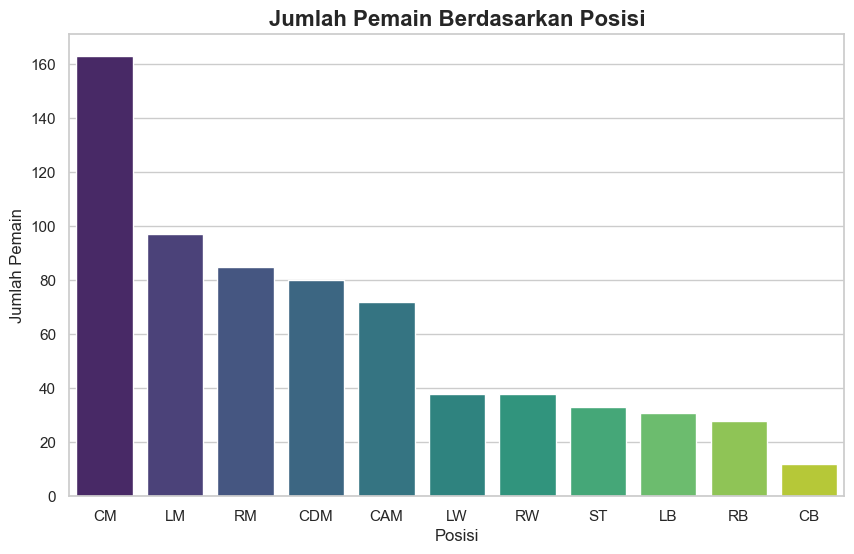

In [6]:
plt.figure(figsize=(10, 6))
order_posisi = df_master['alternatePositions/0/shortLabel'].value_counts().index
sns.countplot(data=df_master, x='alternatePositions/0/shortLabel', order=order_posisi, palette='viridis')
plt.title('Jumlah Pemain Berdasarkan Posisi', fontsize=16, fontweight='bold')
plt.xlabel('Posisi', fontsize=12)
plt.ylabel('Jumlah Pemain', fontsize=12)
plt.show()

### Count Plot Jumlah Pemain Berdasarkan Posisi
- **value_counts()**: Menghitung berapa banyak pemain di setiap posisi
- **order_posisi**: Menyimpan urutan posisi berdasarkan jumlah pemain (dari yang paling banyak ke paling sedikit)
- **sns.countplot()**: Membuat bar chart yang menunjukkan jumlah pemain untuk setiap posisi
  - **palette='viridis'**: Menggunakan palet warna "viridis" (warna yang beragam dari ungu ke kuning)
  - **order=order_posisi**: Menampilkan posisi sesuai urutan yang sudah ditentukan

In [7]:
df_master.corr(numeric_only=True)

,id,rank,overallRating,height,skillMoves,weakFootAbility,preferredFoot,weight,alternatePositions/0/id,gender/id,...,stats/standingTackle/value,stats/standingTackle/diff,stats/vision/value,stats/vision/diff,stats/volleys/value,stats/volleys/diff,alternatePositions/1/id,alternatePositions/0,alternatePositions/2/id,team
id,1.000000,0.116389,-0.108260,-0.065692,0.086903,0.011180,0.054906,-0.127271,-0.025469,NaN,...,0.133443,NaN,0.029046,NaN,0.005377,NaN,0.016383,NaN,0.171611,NaN
rank,0.116389,1.000000,-0.935568,-0.092783,-0.086075,-0.159868,-0.012002,-0.073218,-0.071943,NaN,...,-0.002954,NaN,-0.216857,NaN,-0.113656,NaN,-0.058690,NaN,0.070810,NaN
overallRating,-0.108260,-0.935568,1.000000,0.094140,0.089980,0.160242,0.006934,0.076637,0.101183,NaN,...,-0.015688,NaN,0.203365,NaN,0.109233,NaN,0.069643,NaN,-0.064661,NaN
height,-0.065692,-0.092783,0.094140,1.000000,-0.548614,-0.081443,-0.111512,0.780945,-0.175722,NaN,...,-0.166441,NaN,-0.529605,NaN,-0.452226,NaN,-0.188538,NaN,0.039791,NaN
skillMoves,0.086903,-0.086075,0.089980,-0.548614,1.000000,0.236431,0.145632,-0.515674,0.424343,NaN,...,0.174223,NaN,0.707428,NaN,0.785169,NaN,0.311973,NaN,0.051631,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
stats/volleys/diff,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alternatePositions/1/id,0.016383,-0.058690,0.069643,-0.188538,0.311973,-0.035935,0.084198,-0.150910,0.152743,NaN,...,-0.430276,NaN,0.181976,NaN,0.313448,NaN,1.000000,NaN,-0.030278,NaN
alternatePositions/0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alternatePositions/2/id,0.171611,0.070810,-0.064661,0.039791,0.051631,0.130537,-0.143762,-0.087872,-0.013518,NaN,...,-0.100125,NaN,0.051170,NaN,0.072249,NaN,-0.030278,NaN,1.000000,NaN


<Axes: >

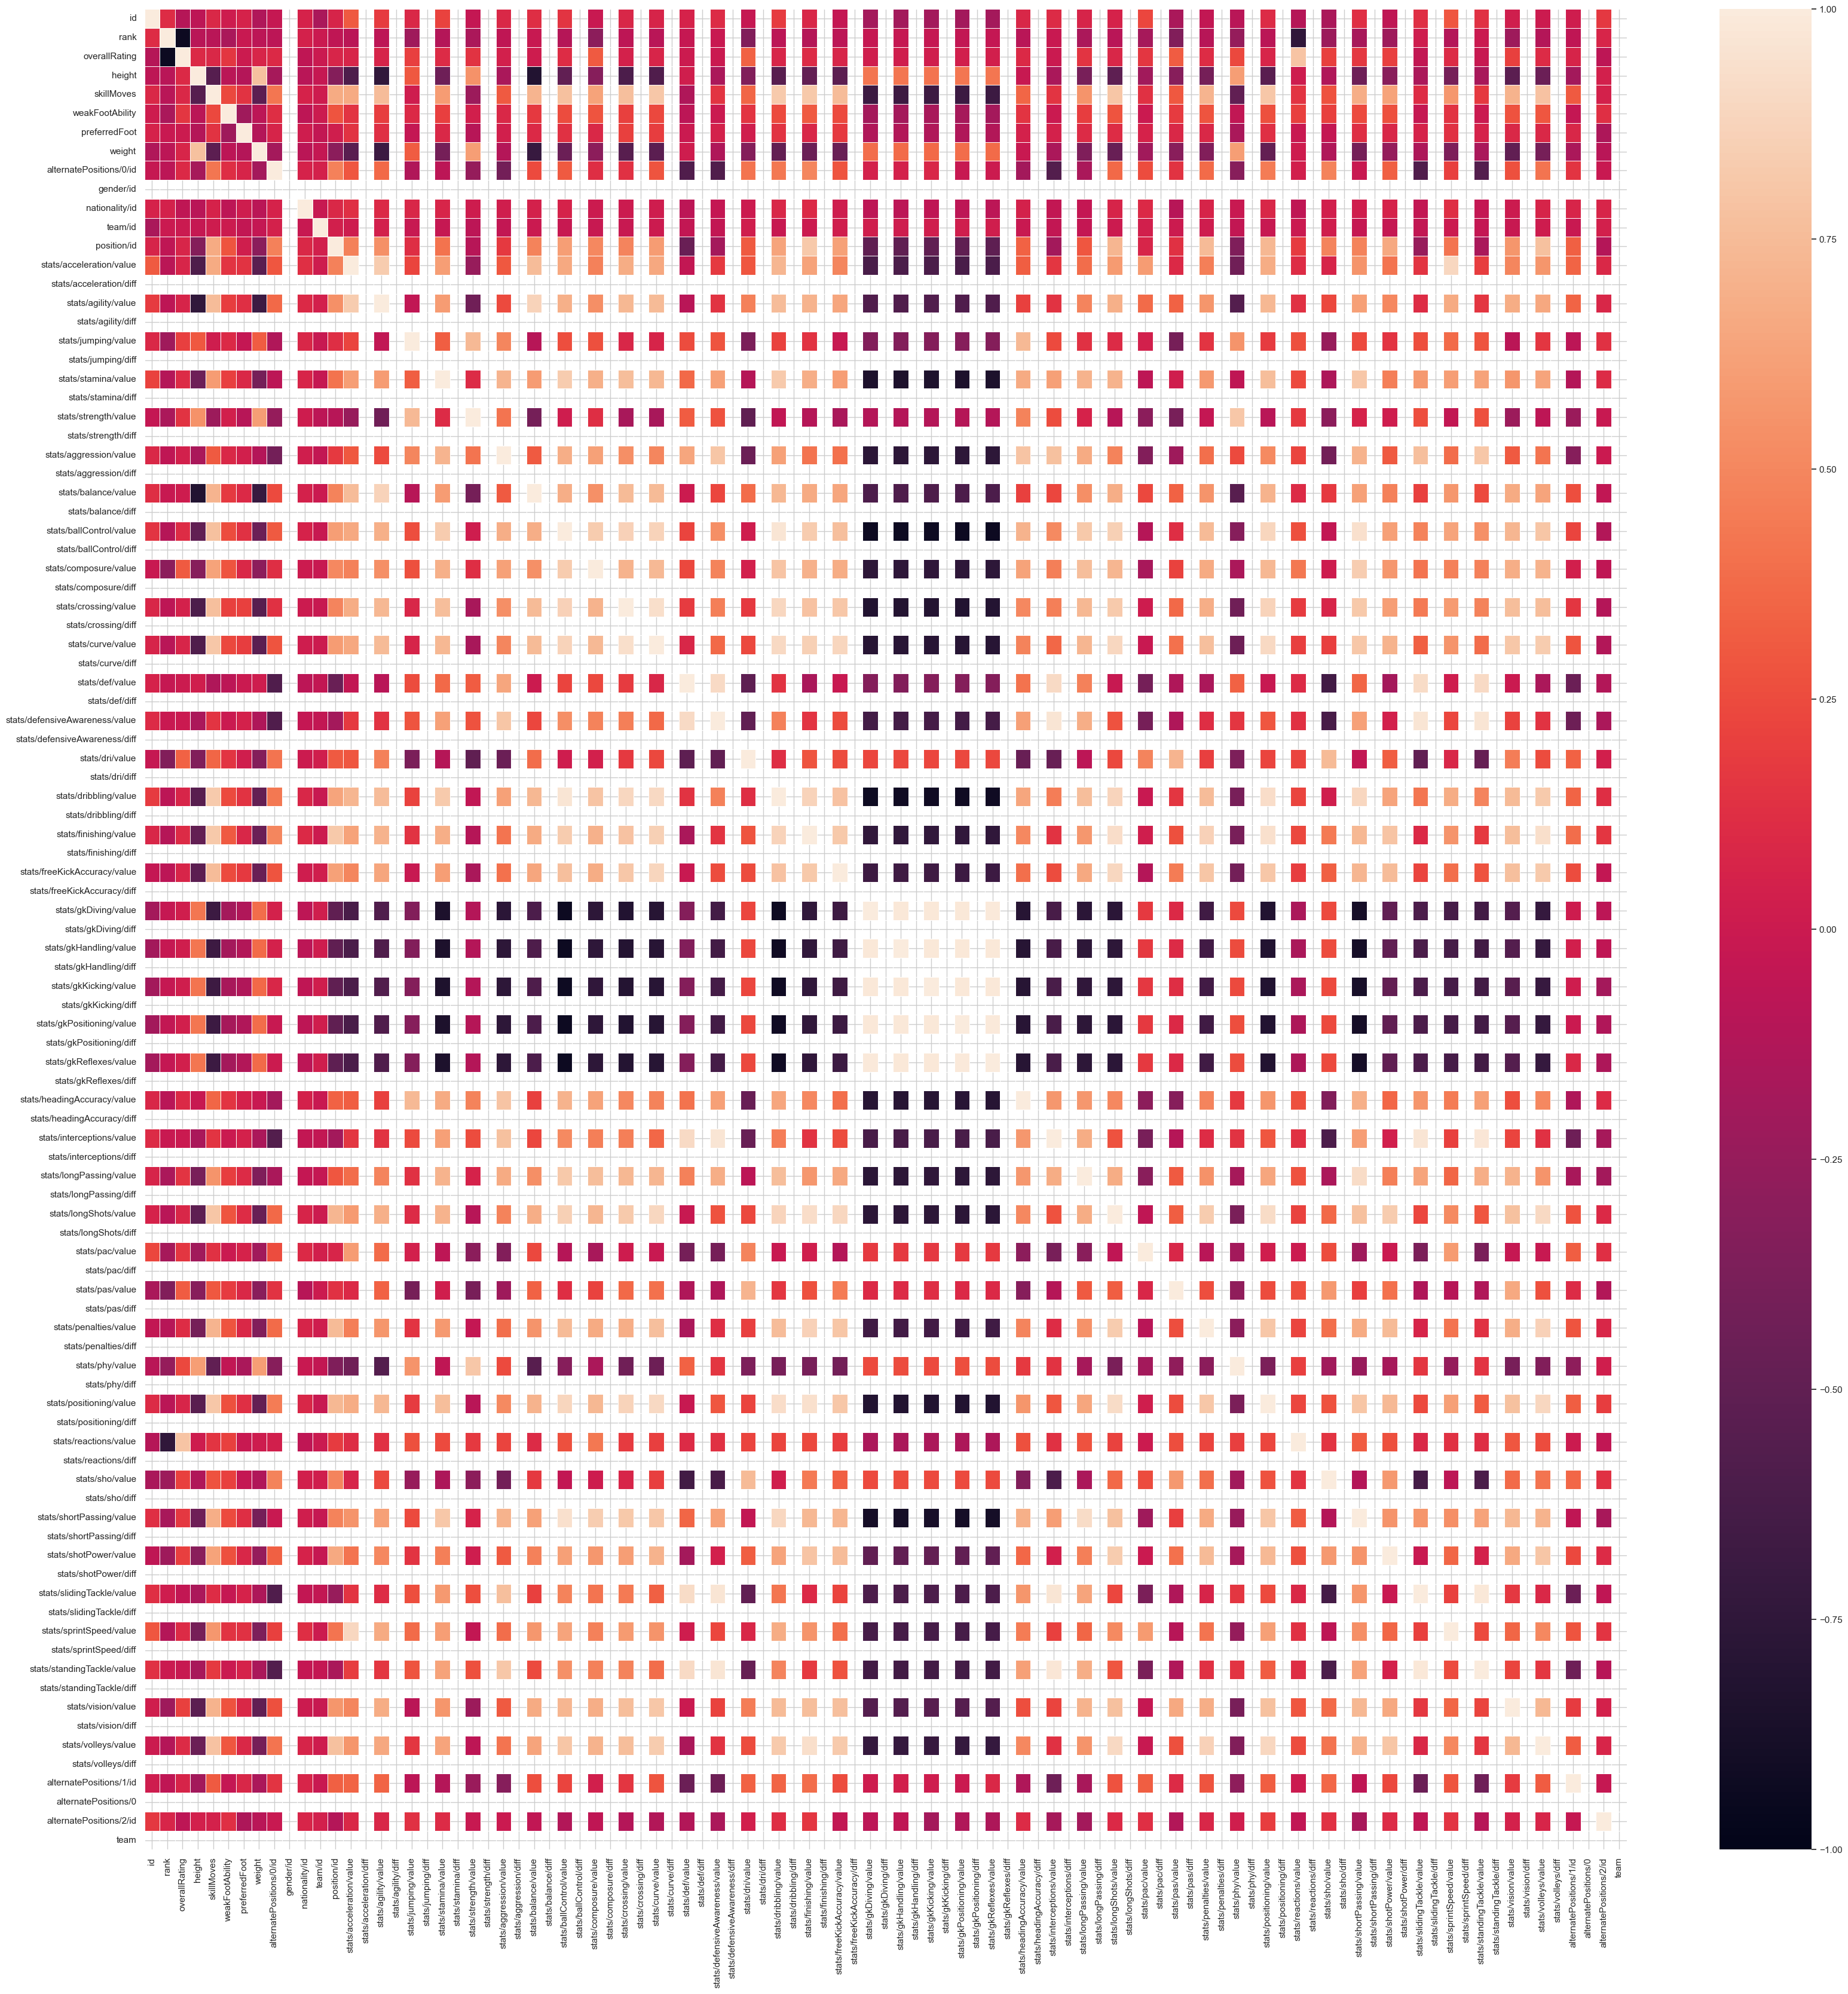

In [66]:
# 1. Atur ukuran kanvas (Lebar 20, Tinggi 18) - Silakan perbesar angkanya jika masih kurang
plt.figure(figsize=(40, 40)) 

# 2. Buat heatmap
sns.heatmap(
    df_master.corr(numeric_only=True), 
    vmin=-1, vmax=1,
    linewidths=0.5
)

### Matriks Korelasi
- **df_master.corr()**: Menghitung korelasi (hubungan) antar kolom numerik dalam dataset
- **numeric_only=True**: Hanya menghitung korelasi untuk kolom bertipe angka, mengabaikan kolom teks
- Hasil menunjukkan nilai korelasi dari -1 (negatif sempurna) hingga +1 (positif sempurna), dengan 0 berarti tidak ada hubungan

In [8]:
df_clean = df_master.copy()
print(list(df_clean.columns.values))
len(list(df_clean.columns.values))

['id', 'rank', 'overallRating', 'firstName', 'lastName', 'commonName', 'birthdate', 'height', 'skillMoves', 'weakFootAbility', 'preferredFoot', 'leagueName', 'weight', 'avatarUrl', 'shieldUrl', 'alternatePositions/0/id', 'alternatePositions/0/label', 'alternatePositions/0/shortLabel', 'playerAbilities/0/id', 'playerAbilities/0/label', 'playerAbilities/0/description', 'playerAbilities/0/imageUrl', 'playerAbilities/0/type/id', 'playerAbilities/0/type/label', 'playerAbilities/1/id', 'playerAbilities/1/label', 'playerAbilities/1/description', 'playerAbilities/1/imageUrl', 'playerAbilities/1/type/id', 'playerAbilities/1/type/label', 'playerAbilities/2/id', 'playerAbilities/2/label', 'playerAbilities/2/description', 'playerAbilities/2/imageUrl', 'playerAbilities/2/type/id', 'playerAbilities/2/type/label', 'playerAbilities/3/id', 'playerAbilities/3/label', 'playerAbilities/3/description', 'playerAbilities/3/imageUrl', 'playerAbilities/3/type/id', 'playerAbilities/3/type/label', 'playerAbiliti

162

### Inisialisasi Data Cleaning
- **df_clean = df_master.copy()**: Membuat salinan dari `df_master` untuk data cleaning tanpa mengubah data asli
- **list(df_clean.columns.values)**: Menampilkan semua nama kolom yang ada
- **len()**: Menghitung jumlah total kolom yang ada

In [9]:
df_clean = df_clean.drop(columns=df_clean.columns[df_clean.columns.str.contains('url', case=False)])
print(list(df_clean.columns.values))
len(list(df_clean.columns.values))

['id', 'rank', 'overallRating', 'firstName', 'lastName', 'commonName', 'birthdate', 'height', 'skillMoves', 'weakFootAbility', 'preferredFoot', 'leagueName', 'weight', 'alternatePositions/0/id', 'alternatePositions/0/label', 'alternatePositions/0/shortLabel', 'playerAbilities/0/id', 'playerAbilities/0/label', 'playerAbilities/0/description', 'playerAbilities/0/type/id', 'playerAbilities/0/type/label', 'playerAbilities/1/id', 'playerAbilities/1/label', 'playerAbilities/1/description', 'playerAbilities/1/type/id', 'playerAbilities/1/type/label', 'playerAbilities/2/id', 'playerAbilities/2/label', 'playerAbilities/2/description', 'playerAbilities/2/type/id', 'playerAbilities/2/type/label', 'playerAbilities/3/id', 'playerAbilities/3/label', 'playerAbilities/3/description', 'playerAbilities/3/type/id', 'playerAbilities/3/type/label', 'playerAbilities/4/id', 'playerAbilities/4/label', 'playerAbilities/4/description', 'playerAbilities/4/type/id', 'playerAbilities/4/type/label', 'playerAbilitie

151

### Menghapus Kolom yang Mengandung 'url'
- **str.contains('url', case=False)**: Mencari semua kolom yang nama-nya mengandung kata "url" (tidak memperhatikan huruf besar/kecil)
- **drop(columns=...)**: Menghapus kolom-kolom tersebut karena URL tidak berguna untuk model machine learning
- Kolom URL biasanya hanya link ke gambar/profil dan tidak memberikan informasi prediktif

In [10]:
df_clean = df_clean.drop(columns=df_clean.columns[df_clean.columns.str.contains('id', case=False)])
print(list(df_clean.columns.values))
len(list(df_clean.columns.values))

['rank', 'overallRating', 'firstName', 'lastName', 'commonName', 'birthdate', 'height', 'skillMoves', 'weakFootAbility', 'preferredFoot', 'leagueName', 'weight', 'alternatePositions/0/label', 'alternatePositions/0/shortLabel', 'playerAbilities/0/label', 'playerAbilities/0/description', 'playerAbilities/0/type/label', 'playerAbilities/1/label', 'playerAbilities/1/description', 'playerAbilities/1/type/label', 'playerAbilities/2/label', 'playerAbilities/2/description', 'playerAbilities/2/type/label', 'playerAbilities/3/label', 'playerAbilities/3/description', 'playerAbilities/3/type/label', 'playerAbilities/4/label', 'playerAbilities/4/description', 'playerAbilities/4/type/label', 'playerAbilities/5/label', 'playerAbilities/5/description', 'playerAbilities/5/type/label', 'playerAbilities/6/label', 'playerAbilities/6/description', 'playerAbilities/6/type/label', 'gender/label', 'nationality/label', 'team/label', 'team/isPopular', 'position/shortLabel', 'position/label', 'position/positionT

126

### Menghapus Kolom yang Mengandung 'id'
- **str.contains('id', case=False)**: Mencari semua kolom yang nama-nya mengandung kata "id"
- **drop(columns=...)**: Menghapus kolom ID karena setiap pemain memiliki ID unik yang tidak berguna untuk prediksi
- ID hanya digunakan untuk identifikasi unik, bukan untuk model pembelajaran

In [11]:
df_clean = df_clean.drop(columns=df_clean.columns[df_clean.columns.str.contains('diff', case=False)])
print(list(df_clean.columns.values))
len(list(df_clean.columns.values))

['rank', 'overallRating', 'firstName', 'lastName', 'commonName', 'birthdate', 'height', 'skillMoves', 'weakFootAbility', 'preferredFoot', 'leagueName', 'weight', 'alternatePositions/0/label', 'alternatePositions/0/shortLabel', 'playerAbilities/0/label', 'playerAbilities/0/description', 'playerAbilities/0/type/label', 'playerAbilities/1/label', 'playerAbilities/1/description', 'playerAbilities/1/type/label', 'playerAbilities/2/label', 'playerAbilities/2/description', 'playerAbilities/2/type/label', 'playerAbilities/3/label', 'playerAbilities/3/description', 'playerAbilities/3/type/label', 'playerAbilities/4/label', 'playerAbilities/4/description', 'playerAbilities/4/type/label', 'playerAbilities/5/label', 'playerAbilities/5/description', 'playerAbilities/5/type/label', 'playerAbilities/6/label', 'playerAbilities/6/description', 'playerAbilities/6/type/label', 'gender/label', 'nationality/label', 'team/label', 'team/isPopular', 'position/shortLabel', 'position/label', 'position/positionT

87

### Menghapus Kolom yang Mengandung 'diff'
- **str.contains('diff', case=False)**: Mencari semua kolom yang nama-nya mengandung kata "diff"
- **drop(columns=...)**: Menghapus kolom "diff" (difference/perbedaan) karena mungkin redundan atau tidak relevan untuk prediksi
- Kolom ini biasanya menunjukkan perbedaan nilai (misalnya rating sebelum dan sesudah), yang dapat diganti dengan nilai absolut

<Axes: >

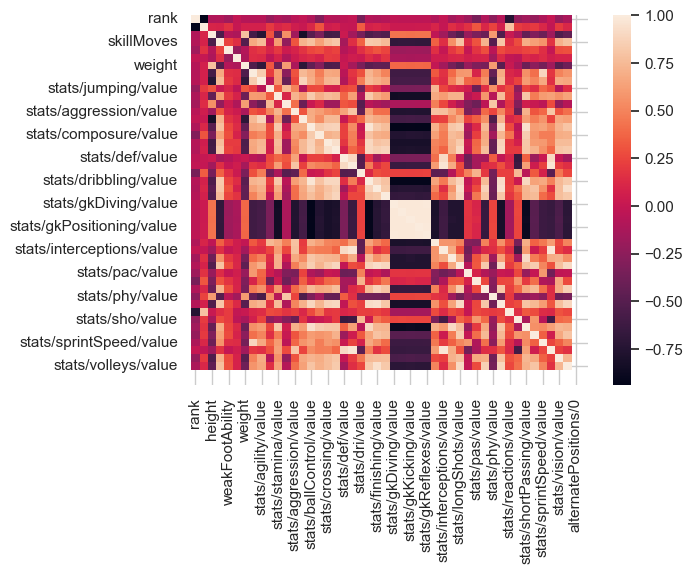

In [12]:
sns.heatmap(df_clean.corr(numeric_only=True))

### Heatmap Korelasi Data Bersih
- **sns.heatmap()**: Membuat visualisasi heatmap dari matriks korelasi
- Warna gelap menunjukkan korelasi negatif (hubungan terbalik), warna terang menunjukkan korelasi positif (hubungan searah)
- Ini membantu mengidentifikasi fitur-fitur mana yang sangat berkaitan dan mungkin redundan

In [13]:
df_clean.select_dtypes(include=['number'])

,rank,overallRating,height,skillMoves,weakFootAbility,preferredFoot,weight,stats/acceleration/value,stats/agility/value,stats/jumping/value,...,stats/reactions/value,stats/sho/value,stats/shortPassing/value,stats/shotPower/value,stats/sprintSpeed/value,stats/standingTackle/value,stats/vision/value,stats/volleys/value,alternatePositions/0,team
0,1,91,175,4,3,2,72,88,86,79,...,94,88,88,83,89,43,89,83,NaN,NaN
1,3,91,182,5,4,1,75,97,93,90,...,91,90,87,91,97,34,83,87,NaN,NaN
2,5,90,178,5,5,2,67,93,94,84,...,91,88,89,91,89,49,84,79,NaN,NaN
3,6,90,190,3,4,1,82,65,66,83,...,93,80,93,92,65,87,84,71,NaN,NaN
4,8,90,193,2,3,1,92,66,54,89,...,90,60,80,81,78,91,70,45,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1306,77,186,3,3,1,73,61,68,72,...,73,70,80,73,67,78,76,65,NaN,NaN
996,1307,77,175,4,3,1,62,78,87,72,...,73,74,77,76,73,71,76,58,NaN,NaN
997,1308,77,179,4,3,2,73,87,84,70,...,74,67,72,70,92,66,70,58,NaN,NaN
998,1309,77,195,1,3,1,94,56,58,75,...,74,75,48,56,54,18,59,16,NaN,NaN


### Menampilkan Kolom Numerik
- **select_dtypes(include=['number'])**: Memilih hanya kolom-kolom yang bertipe data numerik (int, float)
- Berguna untuk melihat berapa banyak fitur numerik yang tersedia setelah pembersihan

In [14]:
list(df_clean.columns.values)

['rank',
 'overallRating',
 'firstName',
 'lastName',
 'commonName',
 'birthdate',
 'height',
 'skillMoves',
 'weakFootAbility',
 'preferredFoot',
 'leagueName',
 'weight',
 'alternatePositions/0/label',
 'alternatePositions/0/shortLabel',
 'playerAbilities/0/label',
 'playerAbilities/0/description',
 'playerAbilities/0/type/label',
 'playerAbilities/1/label',
 'playerAbilities/1/description',
 'playerAbilities/1/type/label',
 'playerAbilities/2/label',
 'playerAbilities/2/description',
 'playerAbilities/2/type/label',
 'playerAbilities/3/label',
 'playerAbilities/3/description',
 'playerAbilities/3/type/label',
 'playerAbilities/4/label',
 'playerAbilities/4/description',
 'playerAbilities/4/type/label',
 'playerAbilities/5/label',
 'playerAbilities/5/description',
 'playerAbilities/5/type/label',
 'playerAbilities/6/label',
 'playerAbilities/6/description',
 'playerAbilities/6/type/label',
 'gender/label',
 'nationality/label',
 'team/label',
 'team/isPopular',
 'position/shortLabel'

### Menampilkan Semua Nama Kolom
- **list(df_clean.columns.values)**: Menampilkan daftar lengkap semua kolom yang masih tersisa setelah penghapusan
- Digunakan untuk memeriksa kolom mana yang perlu dihapus selanjutnya

In [15]:
df_clean.filter(like='shortLabel')

,alternatePositions/0/shortLabel,position/shortLabel,alternatePositions/1/shortLabel,alternatePositions/2/shortLabel
0,RW,RM,NaN,NaN
1,LW,ST,LM,NaN
2,RW,ST,CAM,NaN
3,CM,CDM,NaN,NaN
4,NaN,CB,NaN,NaN
...,...,...,...,...
995,CDM,CM,NaN,NaN
996,CM,CAM,LW,NaN
997,LB,LM,NaN,NaN
998,NaN,GK,NaN,NaN


### Filter Kolom yang Mengandung 'shortLabel'
- **filter(like='shortLabel')**: Memilih hanya kolom-kolom yang nama-nya mengandung kata "shortLabel"
- Ini untuk melihat kolom mana saja yang berisi label singkat yang mungkin redundan atau tidak berguna

In [16]:
df_clean = df_clean.drop(columns=df_clean.columns[df_clean.columns.str.contains('shortLabel', case=False)])
print(list(df_clean.columns.values))
len(list(df_clean.columns.values))

['rank', 'overallRating', 'firstName', 'lastName', 'commonName', 'birthdate', 'height', 'skillMoves', 'weakFootAbility', 'preferredFoot', 'leagueName', 'weight', 'alternatePositions/0/label', 'playerAbilities/0/label', 'playerAbilities/0/description', 'playerAbilities/0/type/label', 'playerAbilities/1/label', 'playerAbilities/1/description', 'playerAbilities/1/type/label', 'playerAbilities/2/label', 'playerAbilities/2/description', 'playerAbilities/2/type/label', 'playerAbilities/3/label', 'playerAbilities/3/description', 'playerAbilities/3/type/label', 'playerAbilities/4/label', 'playerAbilities/4/description', 'playerAbilities/4/type/label', 'playerAbilities/5/label', 'playerAbilities/5/description', 'playerAbilities/5/type/label', 'playerAbilities/6/label', 'playerAbilities/6/description', 'playerAbilities/6/type/label', 'gender/label', 'nationality/label', 'team/label', 'team/isPopular', 'position/label', 'position/positionType/name', 'stats/acceleration/value', 'stats/agility/valu

83

### Menghapus Kolom yang Mengandung 'shortLabel'
- **str.contains('shortLabel', case=False)**: Mencari semua kolom yang mengandung kata "shortLabel"
- **drop(columns=...)**: Menghapus kolom-kolom tersebut karena label singkat tidak memberikan informasi prediktif
- Kolom label seringkali redundan dengan kolom kategori yang lebih jelas

In [17]:
df_clean["alternatePositions/0"].unique()

array([nan])

### Melihat Nilai Unik di Kolom 'alternatePositions/0'
- **unique()**: Menampilkan semua nilai unik yang ada dalam kolom ini
- Berguna untuk melihat apa saja posisi alternatif yang dimiliki pemain dan apakah mereka relevan

In [18]:
for col in df_clean.columns:
    if df_clean[col].nunique() <= 1:
        df_clean = df_clean.drop(columns=col)

### Menghapus Kolom dengan Hanya 1 Nilai Unik
- **nunique() <= 1**: Menghitung berapa banyak nilai unik di setiap kolom
- Kolom dengan hanya 1 nilai unik tidak memberikan informasi variasi untuk model (semua pemain memiliki nilai yang sama)
- Loop ini otomatis menghapus semua kolom "konstan" yang tidak berguna

In [19]:
print(list(df_clean.columns.values))
len(list(df_clean.columns.values))

['rank', 'overallRating', 'firstName', 'lastName', 'commonName', 'birthdate', 'height', 'skillMoves', 'weakFootAbility', 'preferredFoot', 'leagueName', 'weight', 'alternatePositions/0/label', 'playerAbilities/0/label', 'playerAbilities/0/description', 'playerAbilities/0/type/label', 'playerAbilities/1/label', 'playerAbilities/1/description', 'playerAbilities/1/type/label', 'playerAbilities/2/label', 'playerAbilities/2/description', 'playerAbilities/2/type/label', 'playerAbilities/3/label', 'playerAbilities/3/description', 'playerAbilities/3/type/label', 'playerAbilities/4/label', 'playerAbilities/4/description', 'playerAbilities/4/type/label', 'playerAbilities/5/label', 'playerAbilities/5/description', 'playerAbilities/5/type/label', 'playerAbilities/6/label', 'playerAbilities/6/description', 'playerAbilities/6/type/label', 'nationality/label', 'team/label', 'team/isPopular', 'position/label', 'position/positionType/name', 'stats/acceleration/value', 'stats/agility/value', 'stats/jumpi

80

### Menampilkan Kolom Setelah Penghapusan Konstan
- **list(df_clean.columns.values)**: Menampilkan nama-nama kolom yang tersisa
- **len()**: Menampilkan jumlah total kolom yang tersisa setelah pembersihan

In [20]:
list(df_clean.columns.values)

['rank',
 'overallRating',
 'firstName',
 'lastName',
 'commonName',
 'birthdate',
 'height',
 'skillMoves',
 'weakFootAbility',
 'preferredFoot',
 'leagueName',
 'weight',
 'alternatePositions/0/label',
 'playerAbilities/0/label',
 'playerAbilities/0/description',
 'playerAbilities/0/type/label',
 'playerAbilities/1/label',
 'playerAbilities/1/description',
 'playerAbilities/1/type/label',
 'playerAbilities/2/label',
 'playerAbilities/2/description',
 'playerAbilities/2/type/label',
 'playerAbilities/3/label',
 'playerAbilities/3/description',
 'playerAbilities/3/type/label',
 'playerAbilities/4/label',
 'playerAbilities/4/description',
 'playerAbilities/4/type/label',
 'playerAbilities/5/label',
 'playerAbilities/5/description',
 'playerAbilities/5/type/label',
 'playerAbilities/6/label',
 'playerAbilities/6/description',
 'playerAbilities/6/type/label',
 'nationality/label',
 'team/label',
 'team/isPopular',
 'position/label',
 'position/positionType/name',
 'stats/acceleration/valu

### Verifikasi Kolom Final
- **list(df_clean.columns.values)**: Menampilkan daftar lengkap kolom yang akan digunakan untuk analisis lebih lanjut
- Ini adalah checkpoint untuk memastikan semua kolom yang tidak relevan sudah dihapus

<Axes: >

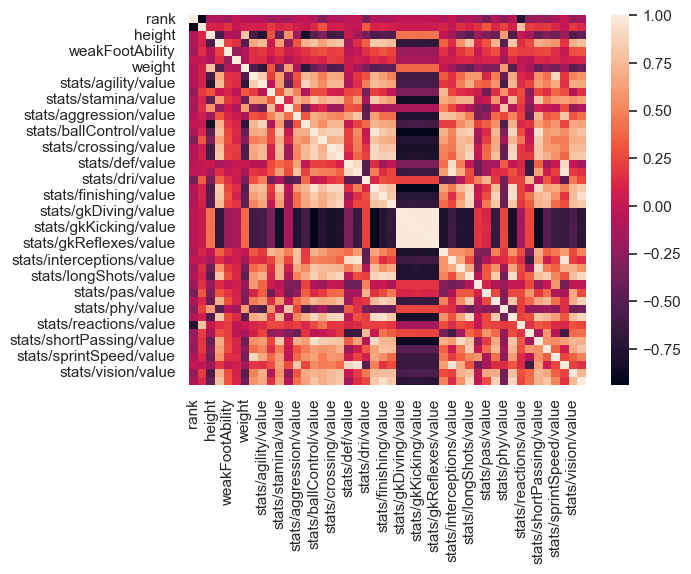

In [21]:
sns.heatmap(df_clean.corr(numeric_only=True))

### Heatmap Korelasi Setelah Cleaning
- **sns.heatmap()**: Membuat visualisasi heatmap dari matriks korelasi data yang sudah dibersihkan
- Menunjukkan hubungan antar fitur setelah penghapusan kolom yang tidak relevan
- Membantu mengidentifikasi multikolinearitas (fitur-fitur yang terlalu berkorelasi satu sama lain)

In [22]:
df_stats = df_clean.copy()
df_stats = df_stats.drop(columns=df_stats.columns[~df_stats.columns.str.contains("stats", case=False)])
print(list(df_stats.columns.values))
len(list(df_stats.columns.values))


['stats/acceleration/value', 'stats/agility/value', 'stats/jumping/value', 'stats/stamina/value', 'stats/strength/value', 'stats/aggression/value', 'stats/balance/value', 'stats/ballControl/value', 'stats/composure/value', 'stats/crossing/value', 'stats/curve/value', 'stats/def/value', 'stats/defensiveAwareness/value', 'stats/dri/value', 'stats/dribbling/value', 'stats/finishing/value', 'stats/freeKickAccuracy/value', 'stats/gkDiving/value', 'stats/gkHandling/value', 'stats/gkKicking/value', 'stats/gkPositioning/value', 'stats/gkReflexes/value', 'stats/headingAccuracy/value', 'stats/interceptions/value', 'stats/longPassing/value', 'stats/longShots/value', 'stats/pac/value', 'stats/pas/value', 'stats/penalties/value', 'stats/phy/value', 'stats/positioning/value', 'stats/reactions/value', 'stats/sho/value', 'stats/shortPassing/value', 'stats/shotPower/value', 'stats/sprintSpeed/value', 'stats/standingTackle/value', 'stats/vision/value', 'stats/volleys/value']


39

### Ekstraksi Kolom yang Mengandung 'stats'
- **df_stats = df_clean.copy()**: Membuat salinan untuk analisis statistik pemain
- **filter(like='stats')**: Memilih hanya kolom-kolom yang mengandung "stats" (statistik performa pemain)
- **drop(columns=...)**: Menghapus kolom yang TIDAK mengandung "stats" agar hanya tinggal kolom statistik
- Ini memisahkan data statistik performa dari informasi lainnya untuk analisis khusus

In [23]:
df_gk_stats = df_stats.copy()
df_gk_stats = df_gk_stats.drop(columns=df_gk_stats.columns[~df_gk_stats.columns.str.contains("gk", case=False)])

df_stats = df_stats.drop(columns=df_stats.columns[df_stats.columns.str.contains("gk", case=False)])
print(list(df_gk_stats.columns.values))
len(list(df_gk_stats.columns.values))
print("")
print(list(df_stats.columns.values))
len(list(df_stats.columns.values))

['stats/gkDiving/value', 'stats/gkHandling/value', 'stats/gkKicking/value', 'stats/gkPositioning/value', 'stats/gkReflexes/value']

['stats/acceleration/value', 'stats/agility/value', 'stats/jumping/value', 'stats/stamina/value', 'stats/strength/value', 'stats/aggression/value', 'stats/balance/value', 'stats/ballControl/value', 'stats/composure/value', 'stats/crossing/value', 'stats/curve/value', 'stats/def/value', 'stats/defensiveAwareness/value', 'stats/dri/value', 'stats/dribbling/value', 'stats/finishing/value', 'stats/freeKickAccuracy/value', 'stats/headingAccuracy/value', 'stats/interceptions/value', 'stats/longPassing/value', 'stats/longShots/value', 'stats/pac/value', 'stats/pas/value', 'stats/penalties/value', 'stats/phy/value', 'stats/positioning/value', 'stats/reactions/value', 'stats/sho/value', 'stats/shortPassing/value', 'stats/shotPower/value', 'stats/sprintSpeed/value', 'stats/standingTackle/value', 'stats/vision/value', 'stats/volleys/value']


34

### Pemisahan Statistik Kiper (GK) dan Pemain Lapangan
- **df_gk_stats = df_stats.copy()**: Membuat salinan untuk statistik kiper
- **contains('gk', case=False)**: Mencari kolom-kolom yang mengandung "gk" (goalkeeper)
- **df_gk_stats**: Menyimpan hanya kolom statistik kiper
- **df_stats**: Menghapus kolom GK sehingga hanya menyimpan statistik pemain lapangan
- Pemisahan ini penting karena kiper dan pemain lapangan memiliki statistik yang berbeda dan tidak sebanding

<Axes: >

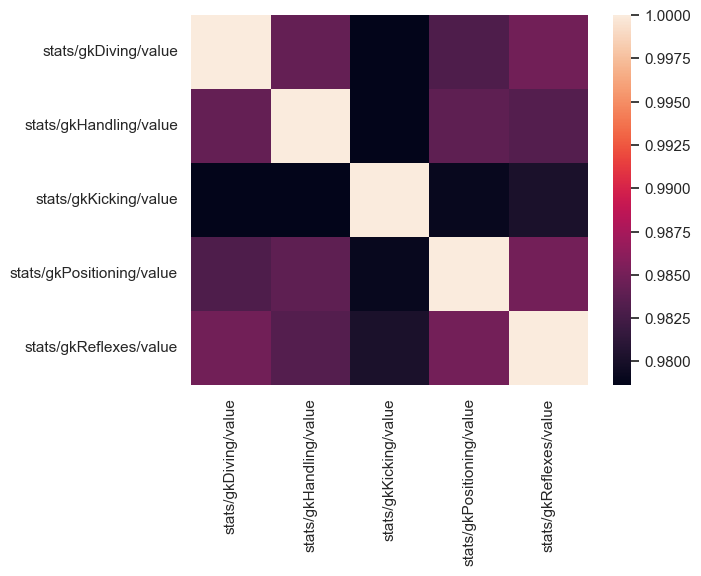

In [24]:
sns.heatmap(df_gk_stats.corr())

### Heatmap Korelasi Statistik Kiper
- **sns.heatmap(df_gk_stats.corr())**: Membuat heatmap untuk melihat korelasi antar statistik kiper
- Menunjukkan hubungan antar atribut kiper seperti diving, handling, reflexes, dll.
- Membantu memahami pola hubungan statistik yang spesifik untuk posisi kiper

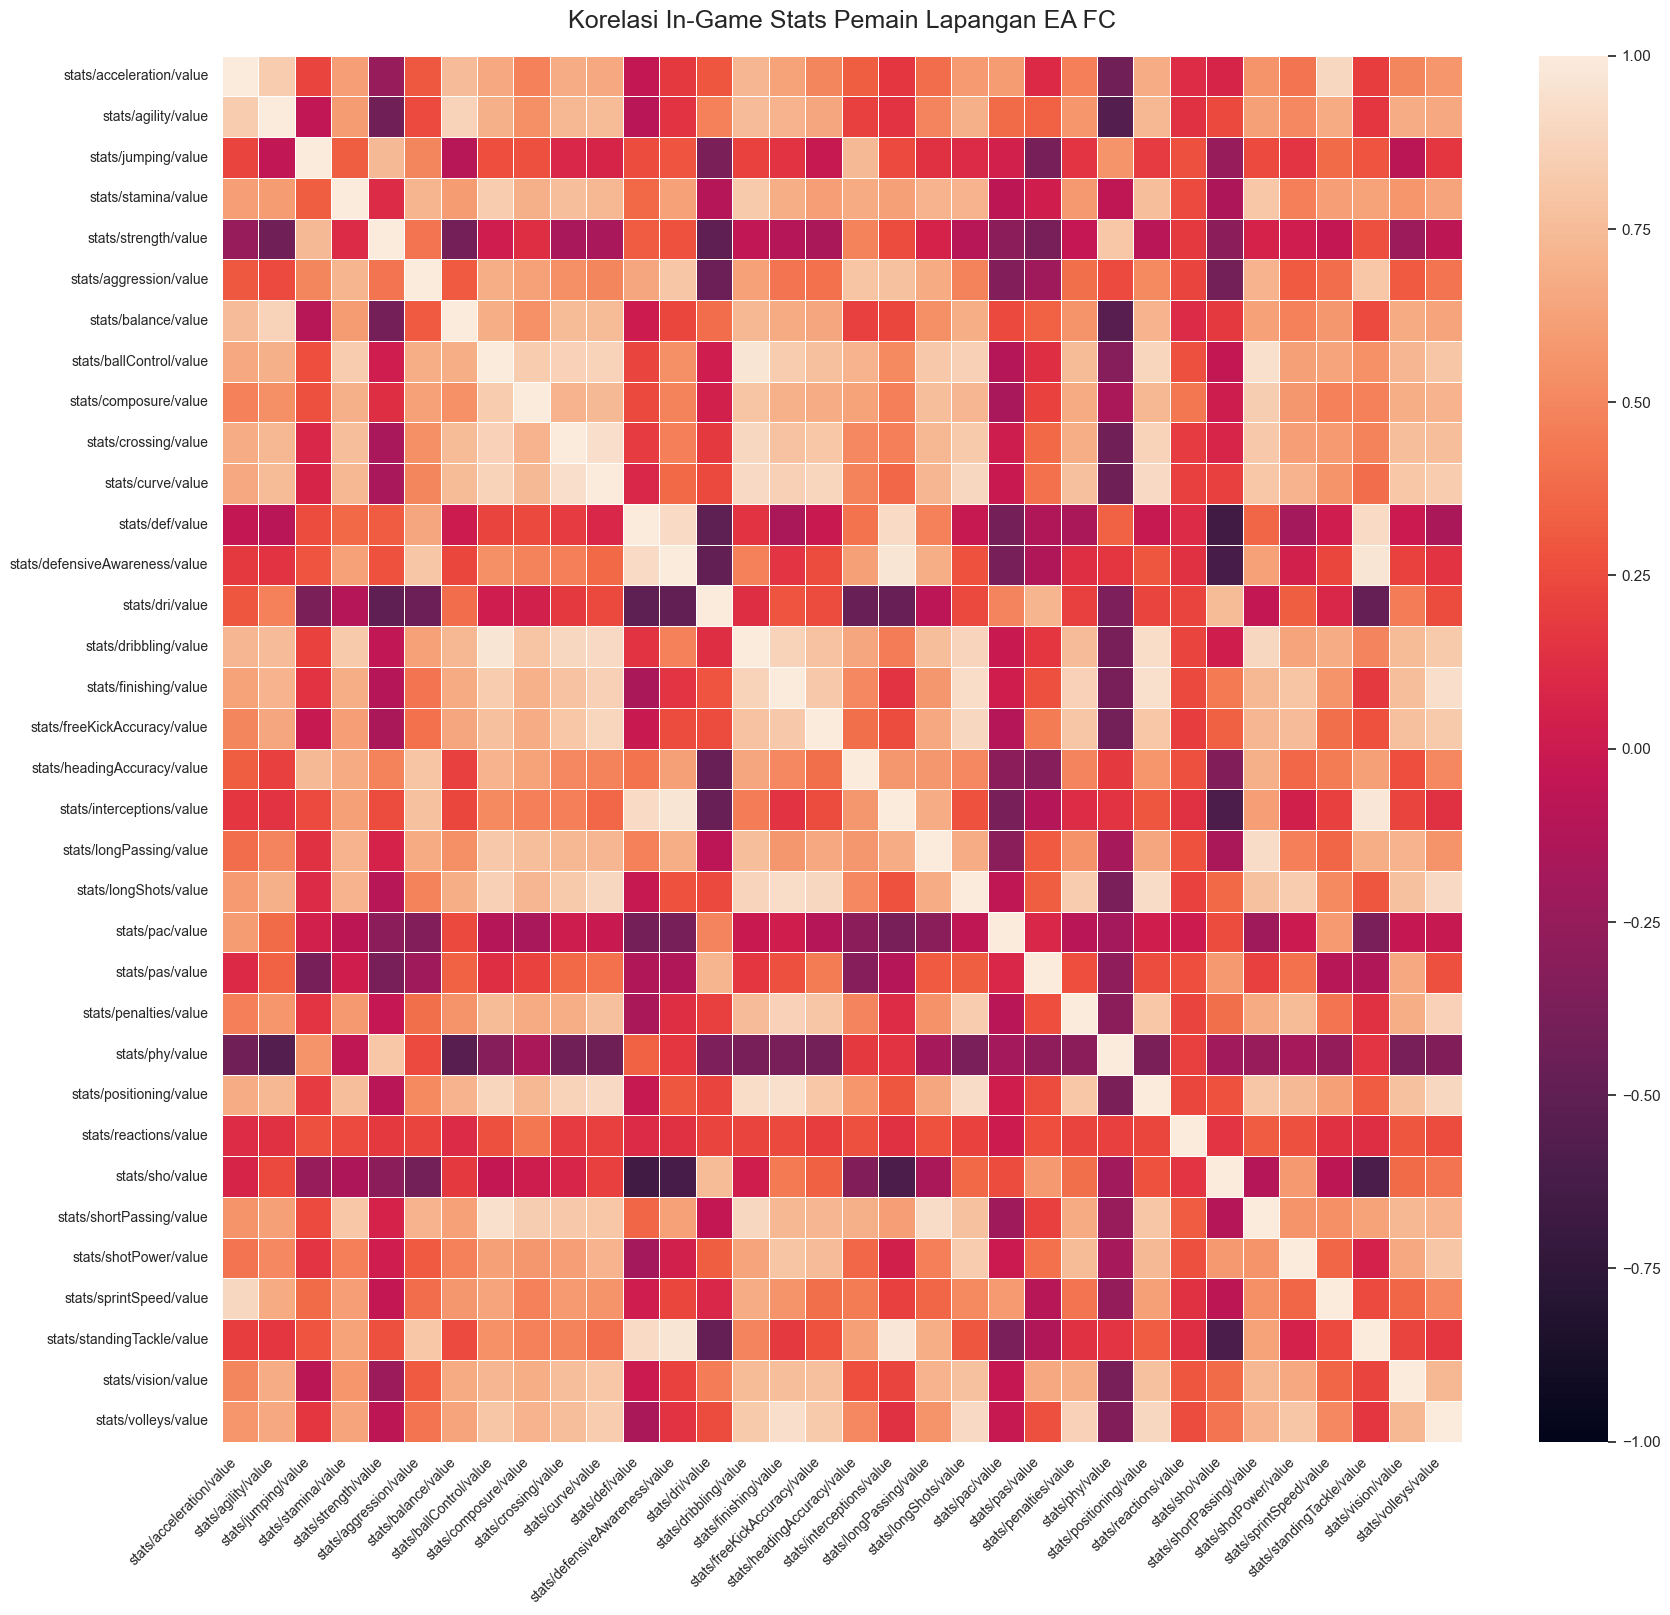

In [25]:
# 1. Atur ukuran kanvas (Lebar 20, Tinggi 18) - Silakan perbesar angkanya jika masih kurang
plt.figure(figsize=(20, 18)) 

# 2. Buat heatmap
sns.heatmap(
    df_stats.corr(numeric_only=True), 
    vmin=-1, vmax=1,
    linewidths=0.5
)

# 3. Trik agar tulisan nama kolom di bawah (sumbu X) sedikit miring dan rapi
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.title("Korelasi In-Game Stats Pemain Lapangan EA FC", fontsize=18, pad=20)

# 4. Tampilkan grafik
plt.show()

### Heatmap Korelasi Statistik Pemain Lapangan (Besar)
- **figsize=(20, 18)**: Membuat kanvas yang besar untuk menampilkan heatmap dengan lebih jelas
- **sns.heatmap()**: Membuat heatmap dari korelasi statistik pemain lapangan
  - **vmin=-1, vmax=1**: Skala warna dari -1 (korelasi negatif sempurna) hingga +1 (positif sempurna)
  - **linewidths=0.5**: Menambahkan garis pemisah antar cell agar lebih mudah dibaca
- **plt.xticks(rotation=45)**: Memutar label kolom 45 derajat agar tidak tumpang tindih
- Hasil menunjukkan hubungan antar atribut seperti pace, shooting, passing, dribbling, defense, physical

In [ ]:
kolom_buang = ['stats/pac/value', 'stats/sho/value', 
               'stats/pas/value', 'stats/dri/value', 
               'stats/def/value', 'stats/phy/value',
               'stats/sprintSpeed/value', 'stats/interceptions/value',
               'stats/longShots/value', 'stats/curve/value',
               'rank', 'birthdate', 'overallRating', 'team/isPopular']

df_clean = df_clean.drop(columns=kolom_buang)
list(df_clean.columns.values)

['firstName',
 'lastName',
 'commonName',
 'height',
 'skillMoves',
 'weakFootAbility',
 'preferredFoot',
 'leagueName',
 'weight',
 'alternatePositions/0/label',
 'playerAbilities/0/label',
 'playerAbilities/0/description',
 'playerAbilities/0/type/label',
 'playerAbilities/1/label',
 'playerAbilities/1/description',
 'playerAbilities/1/type/label',
 'playerAbilities/2/label',
 'playerAbilities/2/description',
 'playerAbilities/2/type/label',
 'playerAbilities/3/label',
 'playerAbilities/3/description',
 'playerAbilities/3/type/label',
 'playerAbilities/4/label',
 'playerAbilities/4/description',
 'playerAbilities/4/type/label',
 'playerAbilities/5/label',
 'playerAbilities/5/description',
 'playerAbilities/5/type/label',
 'playerAbilities/6/label',
 'playerAbilities/6/description',
 'playerAbilities/6/type/label',
 'nationality/label',
 'team/label',
 'position/label',
 'position/positionType/name',
 'stats/acceleration/value',
 'stats/agility/value',
 'stats/jumping/value',
 'stats/

### Menghapus Kolom yang Redundan Berdasarkan Analisis Korelasi
- **kolom_buang**: List kolom-kolom yang dipilih untuk dihapus berdasarkan analisis korelasi heatmap
- Kolom-kolom ini dipilih karena:
  - **pac, sho, pas, dri, def, phy**: Statistik umum yang mungkin redundan dengan sub-statistik spesifik
  - **sprintSpeed**: Mungkin tercakup dalam pace
  - **interceptions**: Statistik pertahanan khusus
  - **longShots**: Statistik penembakan khusus
  - **curve**: Statistik teknis yang spesifik
  - **rank, birthdate, overallRating**: Metadata yang tidak perlu untuk analisis komparatif
  - **team/isPopular**: Informasi tim yang tidak relevan untuk atribut pemain
- **drop(columns=...)**: Menghapus semua kolom dalam list tersebut

In [27]:
kamus_nama = {
    'position/label': 'position_name',
    'team/label': 'team_name',
    'nationality/label': 'nationality'
}

# Terapkan ke DataFrame
df_clean = df_clean.rename(columns=kamus_nama)

# 1. Buang awalan 'stats/'
df_clean.columns = df_clean.columns.str.replace('stats/', '')

# 2. Buang akhiran '/value'
df_clean.columns = df_clean.columns.str.replace('/value', '')

# 3. (Opsional) Mengganti '/' menjadi '_' untuk kolom lain agar lebih aman di Python
df_clean.columns = df_clean.columns.str.replace('/', '_')


# Cek hasilnya
print(list(df_clean.columns.values))

['firstName', 'lastName', 'commonName', 'height', 'skillMoves', 'weakFootAbility', 'preferredFoot', 'leagueName', 'weight', 'alternatePositions_0_label', 'playerAbilities_0_label', 'playerAbilities_0_description', 'playerAbilities_0_type_label', 'playerAbilities_1_label', 'playerAbilities_1_description', 'playerAbilities_1_type_label', 'playerAbilities_2_label', 'playerAbilities_2_description', 'playerAbilities_2_type_label', 'playerAbilities_3_label', 'playerAbilities_3_description', 'playerAbilities_3_type_label', 'playerAbilities_4_label', 'playerAbilities_4_description', 'playerAbilities_4_type_label', 'playerAbilities_5_label', 'playerAbilities_5_description', 'playerAbilities_5_type_label', 'playerAbilities_6_label', 'playerAbilities_6_description', 'playerAbilities_6_type_label', 'nationality', 'team_name', 'position_name', 'position_positionType_name', 'acceleration', 'agility', 'jumping', 'stamina', 'strength', 'aggression', 'balance', 'ballControl', 'composure', 'crossing', '

### Pembersihan dan Penamaan Ulang Kolom
- **kamus_nama**: Dictionary yang memetakan nama kolom lama ke nama baru yang lebih sederhana
  - 'position/label' → 'position_name': Posisi pemain
  - 'team/label' → 'team_name': Nama tim
  - 'nationality/label' → 'nationality': Kewarganegaraan pemain
- **rename(columns=kamus_nama)**: Mengganti nama kolom sesuai dictionary
- **str.replace('stats/', '')**: Menghapus awalan "stats/" dari semua nama kolom
- **str.replace('/value', '')**: Menghapus akhiran "/value" dari semua nama kolom
- **str.replace('/', '_')**: Mengganti karakter '/' dengan '_' untuk membuat nama kolom lebih aman digunakan di Python
- Hasil: Nama kolom menjadi lebih sederhana dan mudah dibaca (contoh: 'stats/pac/value' → 'pac')

In [28]:
list(df_clean.columns.values)

['firstName',
 'lastName',
 'commonName',
 'height',
 'skillMoves',
 'weakFootAbility',
 'preferredFoot',
 'leagueName',
 'weight',
 'alternatePositions_0_label',
 'playerAbilities_0_label',
 'playerAbilities_0_description',
 'playerAbilities_0_type_label',
 'playerAbilities_1_label',
 'playerAbilities_1_description',
 'playerAbilities_1_type_label',
 'playerAbilities_2_label',
 'playerAbilities_2_description',
 'playerAbilities_2_type_label',
 'playerAbilities_3_label',
 'playerAbilities_3_description',
 'playerAbilities_3_type_label',
 'playerAbilities_4_label',
 'playerAbilities_4_description',
 'playerAbilities_4_type_label',
 'playerAbilities_5_label',
 'playerAbilities_5_description',
 'playerAbilities_5_type_label',
 'playerAbilities_6_label',
 'playerAbilities_6_description',
 'playerAbilities_6_type_label',
 'nationality',
 'team_name',
 'position_name',
 'position_positionType_name',
 'acceleration',
 'agility',
 'jumping',
 'stamina',
 'strength',
 'aggression',
 'balance',


### Verifikasi Kolom Final Setelah Pembersihan
- **list(df_clean.columns.values)**: Menampilkan semua nama kolom akhir yang telah dibersihkan
- Pada tahap ini, dataset sudah siap untuk:
  - Analisis Exploratory Data Analysis (EDA) lebih lanjut
  - Modeling dan training machine learning
  - Pembuatan feature engineering tambahan jika diperlukan

In [29]:
df_clean.to_csv("ea_fc_26_master_fix.csv")

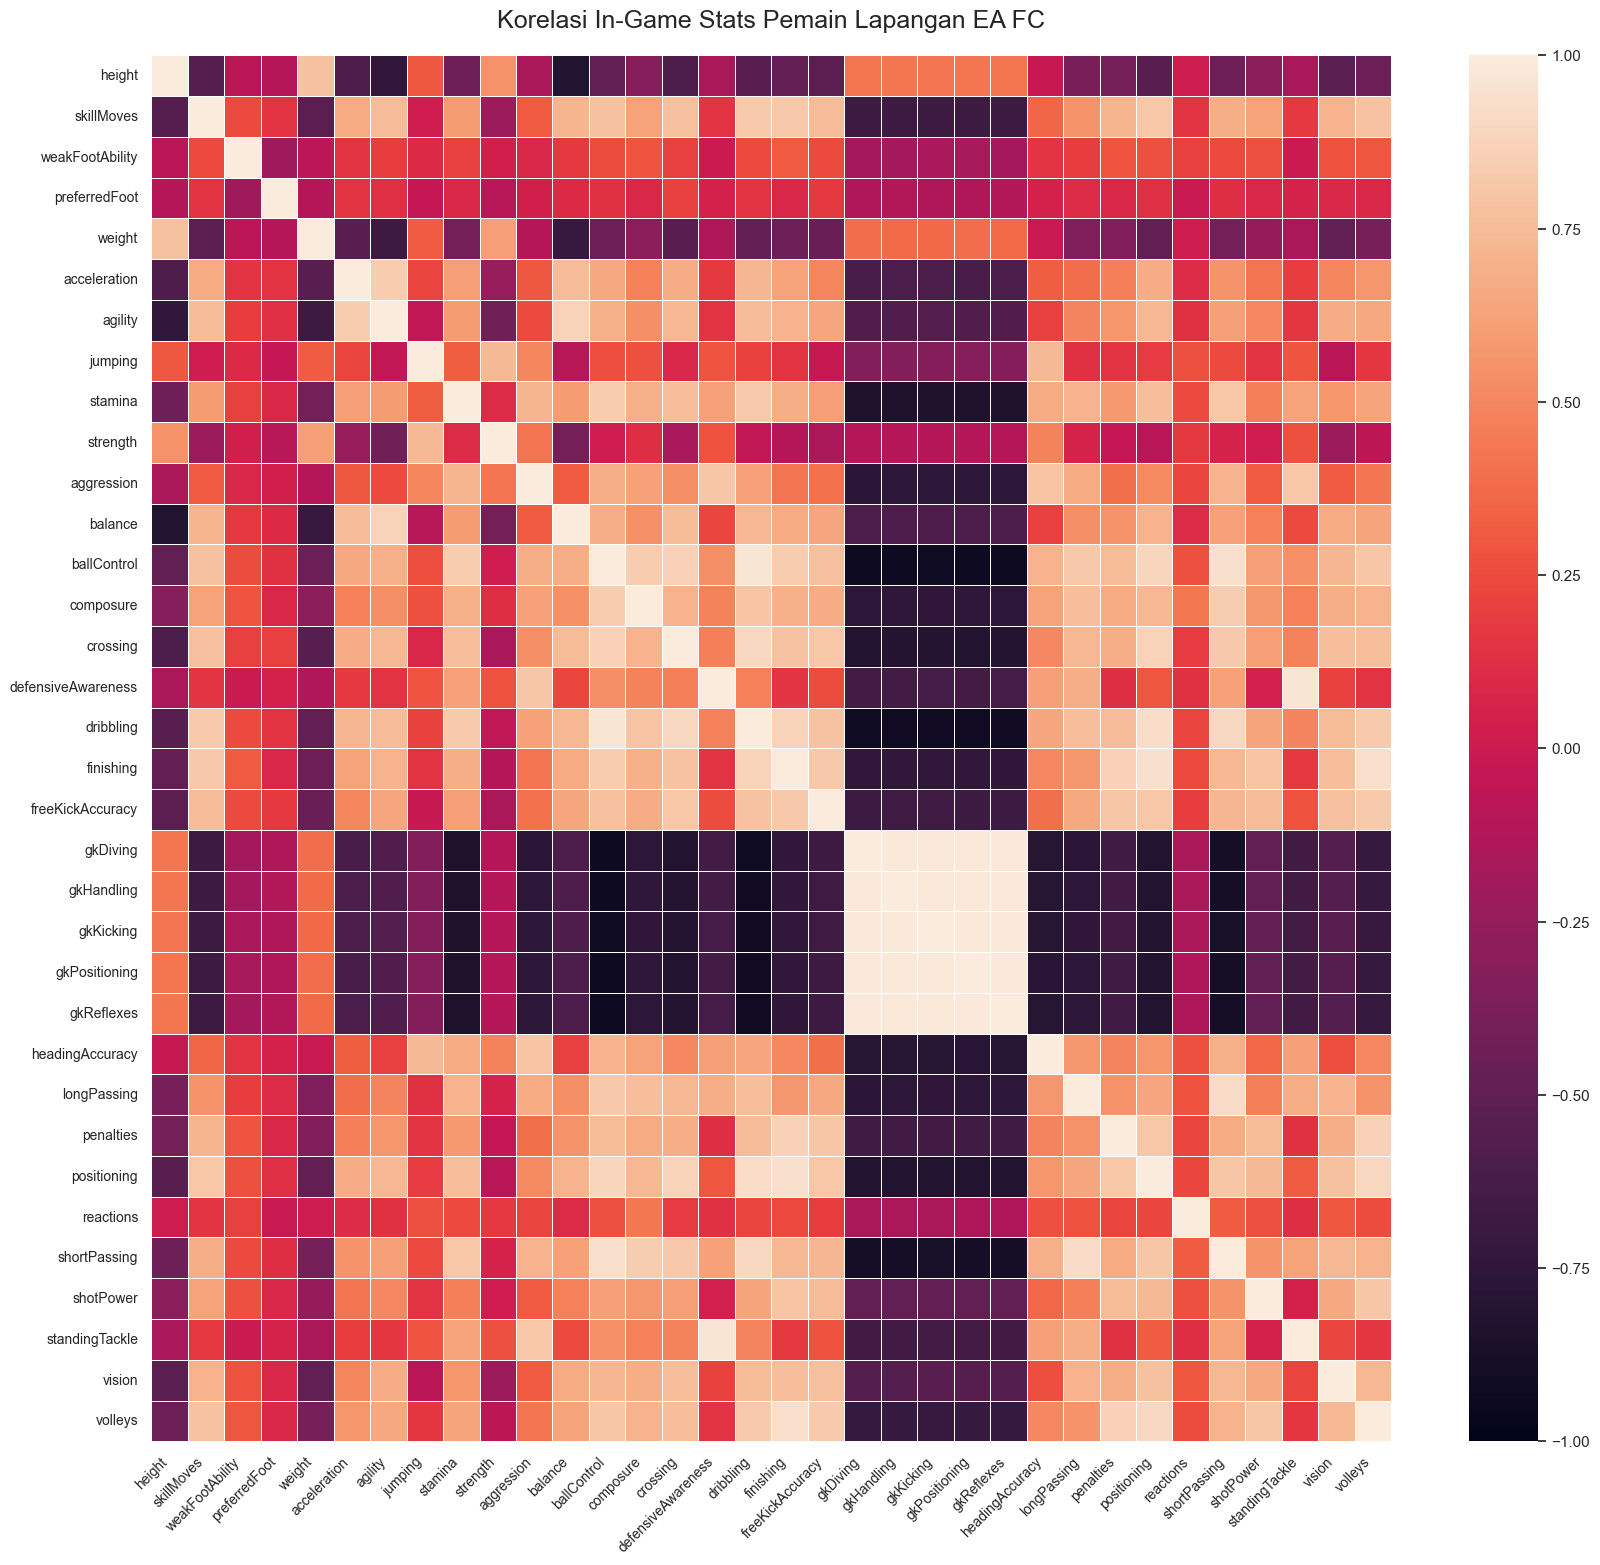

In [30]:
# 1. Atur ukuran kanvas (Lebar 20, Tinggi 18) - Silakan perbesar angkanya jika masih kurang
plt.figure(figsize=(20, 18)) 

# 2. Buat heatmap
sns.heatmap(
    df_clean.corr(numeric_only=True), 
    vmin=-1, vmax=1,
    linewidths=0.5
)

# 3. Trik agar tulisan nama kolom di bawah (sumbu X) sedikit miring dan rapi
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.title("Korelasi In-Game Stats Pemain Lapangan EA FC", fontsize=18, pad=20)

# 4. Tampilkan grafik
plt.show()

In [31]:
fullname = df_clean["firstName"] + " " + df_clean["lastName"] + " '" + df_clean["commonName"].fillna('') + "'" 
fullname = fullname.str.replace(" ''", "").str.strip()

df_clean.insert(0, 'fullName', fullname)
df_clean = df_clean.drop(columns=['firstName', 'lastName', 'commonName'])
df_clean

,fullName,height,skillMoves,weakFootAbility,preferredFoot,leagueName,weight,alternatePositions_0_label,playerAbilities_0_label,playerAbilities_0_description,...,penalties,positioning,reactions,shortPassing,shotPower,standingTackle,vision,volleys,alternatePositions_1_label,alternatePositions_2_label
0,Mohamed Salah,175,4,3,2,Premier League,72,Right Wing,Low Driven Shot,Enhances a player's ability to execute low dri...,...,88,93,94,88,83,43,89,83,NaN,NaN
1,Kylian Mbappé,182,5,4,1,LALIGA EA SPORTS,75,Left Wing,Finesse Shot,Faster finesse shots with more curve and accuracy,...,82,91,91,87,91,34,83,87,Left Midfielder,NaN
2,Ousmane Dembélé,178,5,5,2,Ligue 1 McDonald's,67,Right Wing,Low Driven Shot,Enhances a player's ability to execute low dri...,...,80,95,91,89,91,49,84,79,Center Attacking Midfielder,NaN
3,Rodrigo Hernández Cascante 'Rodri',190,3,4,1,Premier League,82,Center Midfielder,Power Shot,Faster power shots with increased speed,...,62,76,93,93,92,87,84,71,NaN,NaN
4,Virgil van Dijk,193,2,3,1,Premier League,92,NaN,Precision Header,Performs headers with increased accuracy and p...,...,62,47,90,80,81,91,70,45,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Jose Luís García Vayá 'Pepelu',186,3,3,1,LALIGA EA SPORTS,73,Center Defensive Midfielder,Finesse Shot,Faster finesse shots with more curve and accuracy,...,83,69,73,80,73,78,76,65,NaN,NaN
996,Alexis Claude-Maurice,175,4,3,1,Bundesliga,62,Center Midfielder,Technical,"Faster Controlled Sprint, precise wide turns w...",...,65,74,73,77,76,71,76,58,Left Wing,NaN
997,Diego Manuel J. da Silva Moreira 'Diego Moreira',179,4,3,2,Ligue 1 McDonald's,73,Left Back,Gamechanger,Fancy and Trivela shots are performed with imp...,...,60,73,74,72,70,66,70,58,NaN,NaN
998,Alphonse Areola,195,1,3,1,Premier League,94,NaN,Far Throw,Unique goalkeeper throw animations with longer...,...,25,17,74,48,56,18,59,16,NaN,NaN


In [32]:
missing_data = df_clean.isna().sum()
print(missing_data[missing_data > 0])
print(len(df_clean))

alternatePositions_0_label       323
playerAbilities_0_label           51
playerAbilities_0_description     51
playerAbilities_0_type_label      51
playerAbilities_1_label          223
playerAbilities_1_description    223
playerAbilities_1_type_label     223
playerAbilities_2_label          421
playerAbilities_2_description    421
playerAbilities_2_type_label     421
playerAbilities_3_label          614
playerAbilities_3_description    614
playerAbilities_3_type_label     614
playerAbilities_4_label          775
playerAbilities_4_description    775
playerAbilities_4_type_label     775
playerAbilities_5_label          871
playerAbilities_5_description    871
playerAbilities_5_type_label     871
playerAbilities_6_label          943
playerAbilities_6_description    943
playerAbilities_6_type_label     943
team_name                         24
alternatePositions_1_label       671
alternatePositions_2_label       931
dtype: int64
1000


In [33]:
col_mean_nan = df_clean.columns[df_clean.isna().mean() > 0.7]
df_clean = df_clean.drop(columns=col_mean_nan)
list(df_clean.columns.values)

['fullName',
 'height',
 'skillMoves',
 'weakFootAbility',
 'preferredFoot',
 'leagueName',
 'weight',
 'alternatePositions_0_label',
 'playerAbilities_0_label',
 'playerAbilities_0_description',
 'playerAbilities_0_type_label',
 'playerAbilities_1_label',
 'playerAbilities_1_description',
 'playerAbilities_1_type_label',
 'playerAbilities_2_label',
 'playerAbilities_2_description',
 'playerAbilities_2_type_label',
 'playerAbilities_3_label',
 'playerAbilities_3_description',
 'playerAbilities_3_type_label',
 'nationality',
 'team_name',
 'position_name',
 'position_positionType_name',
 'acceleration',
 'agility',
 'jumping',
 'stamina',
 'strength',
 'aggression',
 'balance',
 'ballControl',
 'composure',
 'crossing',
 'defensiveAwareness',
 'dribbling',
 'finishing',
 'freeKickAccuracy',
 'gkDiving',
 'gkHandling',
 'gkKicking',
 'gkPositioning',
 'gkReflexes',
 'headingAccuracy',
 'longPassing',
 'penalties',
 'positioning',
 'reactions',
 'shortPassing',
 'shotPower',
 'standingTac

In [34]:
missing_data = df_clean.isna().sum()
print(missing_data[missing_data > 0])
print(len(df_clean))

alternatePositions_0_label       323
playerAbilities_0_label           51
playerAbilities_0_description     51
playerAbilities_0_type_label      51
playerAbilities_1_label          223
playerAbilities_1_description    223
playerAbilities_1_type_label     223
playerAbilities_2_label          421
playerAbilities_2_description    421
playerAbilities_2_type_label     421
playerAbilities_3_label          614
playerAbilities_3_description    614
playerAbilities_3_type_label     614
team_name                         24
alternatePositions_1_label       671
dtype: int64
1000


In [35]:
df_clean = df_clean.fillna("-")

In [36]:
df_clean.insert(0, 'id', [f"player{i}" for i in range(len(df_clean))])

In [37]:
# df_encoded.dtypes
df_num = df_clean.select_dtypes(int)
df_cat = df_clean.select_dtypes(object)

In [38]:
df_num.insert(0, 'id', df_cat['id'])
df_num.insert(1, 'fullName', df_cat['fullName'])

# df_cat.drop(columns=["team_name", "leagueName"])

In [39]:
# acc_mean = df_num["acceleration"].mean()
# acc_median = df_num["acceleration"].median()
# abs(acc_mean - acc_median) > 1

stand_scaler = StandardScaler()
rob_scaler = RobustScaler()

for i in df_num.iloc[:, 2:].columns:
    if abs(df_num[i].mean()-df_num[i].median()) > 1:
        df_num[i] = rob_scaler.fit_transform(df_num[[i]])
    else:
        df_num[i] = stand_scaler.fit_transform(df_num[[i]])


**One-Hot-Encoding untuk `Department`**  
Pendekatan ini berbeda dari spek soal, seperti pada bagian sebelumnya (pada Data Imputing on Missing Values) dikarenakan:  
- Atribut Department memiliki data yang bersifat nominal (bukan ordinal/bertingkat)  
- Output nya adalah data dengan penjelasan bahwa data tersebut masuk pada kelas mana (Publishin, Design, Research, dsb)
- Pendekkatan ini cocok untuk data nominal yang mengkategorikan data tanpa ada relasi hierarkis

## **Training**  
---  

Cosine Similarity Based On Categorical Only Feature

In [40]:
df_cat["combined"] = df_cat.astype(str).agg(' '.join, axis=1)

In [41]:
cv = CountVectorizer()
count_matrix = cv.fit_transform(df_cat['combined'])
print("Count Matrix: ",count_matrix.toarray())

Count Matrix:  [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [42]:
cosine_sim_cat = cosine_similarity(count_matrix)

In [43]:
def get_id_from(fullName,df):
    hasil_pencarian = df[df['fullName'].str.contains(fullName, case=False, na=False)]
    if len(hasil_pencarian) > 0:
        return hasil_pencarian["id"].index[0]
    else:
        print(f"Pemain dengan nama '{fullName}' tidak ditemukan.")
        return None
    
idx_cat = get_id_from("Casemiro",df_cat)

In [44]:
similar_player_cat = list(enumerate(cosine_sim_cat[idx_cat]))

In [45]:
sorted_similar_player_cat = sorted(similar_player_cat, key = lambda x:x[1], reverse = True)

In [46]:
def get_player_from_id(index,df):
    return df[df.index == index]["fullName"].values[0]

i=0
for player in sorted_similar_player_cat:
    print(get_player_from_id(player[0],df_cat))
    i = i+1;
    if i == 1:
        print("-"*35)
        print("Opsi Pemain Pengganti yang Sesuai: ")
        print("-"*35)
    if i>20:
        break

Carlos Henrique Venancio Casimiro 'Casemiro'
-----------------------------------
Opsi Pemain Pengganti yang Sesuai: 
-----------------------------------
Amir Rrahmani
Dean Huijsen
Fábio Henrique Tavares 'Fabinho'
Idrissa Gueye
Jefferson Lerma
Beñat Prados Díaz 'Beñat Prados'
Mario Hermoso Canseco 'Mario Hermoso'
Sebastián Coates
Charles Vanhoutte
Anton Stach
Andrey N. dos Santos 'Andrey Santos'
Benjamin André
Francesco Acerbi
Amadou Onana
Aschraf El Mahdioui
Kalidou Koulibaly
James Tarkowski
Marten de Roon
Leandro Paredes
Jules Koundé


In [47]:
cosine_sim_num = cosine_similarity(df_num.iloc[:, 2:])

In [48]:
idx = get_id_from("Casemiro", df_num)
similar_player_by_num = list(enumerate(cosine_sim_num[idx]))

In [49]:
sorted_similar_player_by_num = sorted(similar_player_by_num, key = lambda x:x[1], reverse = True)

In [50]:
i=0
for player in sorted_similar_player_by_num:
    print(get_player_from_id(player[0],df_num))
    i = i+1;
    if i == 1:
        print("-"*35)
        print("Opsi Pemain Pengganti yang Sesuai: ")
        print("-"*35)
    if i>15:
        break

Carlos Henrique Venancio Casimiro 'Casemiro'
-----------------------------------
Opsi Pemain Pengganti yang Sesuai: 
-----------------------------------
Harry Maguire
Eric Dier
Florian Lejeune
Joachim Andersen
Niklas Süle
Robert Andrich
Fabian Schär
Matthias Ginter
Danilo Luís Hélio Pereira 'Danilo Pereira'
Nemanja Gudelj
Borja Iglesias Quintás 'Borja Iglesias'
Chris Wood
Ali Al Musrati
Dante Bonfim Costa Santos 'Dante'
Sander Berge


In [51]:
w_cat = 0.2
w_num = 0.8

cosin_sim_final = (cosine_sim_cat * w_cat) + (cosine_sim_num * w_num)

In [52]:
def get_recommendations(nama_pemain, top_n=5):
    hasil_pencarian = df_clean[df_clean['fullName'].str.contains(nama_pemain, case=False, na=False)]
    
    if len(hasil_pencarian) == 0:
        return "Pemain tidak ditemukan"
    
    idx = hasil_pencarian.index[0]
    
    sim_scores = list(enumerate(cosin_sim_final[idx]))
    
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    top_players_idx = [i[0] for i in sim_scores[1:top_n+1]]
    
    return df_clean[["fullName","position_name", "alternatePositions_0_label","team_name"]].iloc[top_players_idx]

# Coba jalankan!
get_recommendations("Casemiro",15)

,fullName,position_name,alternatePositions_0_label,team_name
582,Harry Maguire,Center Back,-,Man Utd
946,Joachim Andersen,Center Back,-,Fulham
460,Niklas Süle,Center Back,Right Back,Borussia Dortmund
938,Florian Lejeune,Center Back,-,Rayo Vallecano
371,Matthias Ginter,Center Back,-,SC Freiburg
342,Fabian Schär,Center Back,-,Newcastle Utd
410,Robert Andrich,Center Defensive Midfielder,Center Midfielder,Leverkusen
151,Nemanja Gudelj,Center Back,Center Defensive Midfielder,Sevilla FC
451,Danilo Luís Hélio Pereira 'Danilo Pereira',Center Back,-,Al Ittihad
585,James Tarkowski,Center Back,-,Everton


In [53]:
df_clean.to_csv("players_dataset_fix.csv")

In [65]:
df_master.select_dtypes(int)

,id,rank,overallRating,height,skillMoves,weakFootAbility,preferredFoot,weight,gender/id,nationality/id,...,stats/slidingTackle/value,stats/slidingTackle/diff,stats/sprintSpeed/value,stats/sprintSpeed/diff,stats/standingTackle/value,stats/standingTackle/diff,stats/vision/value,stats/vision/diff,stats/volleys/value,stats/volleys/diff
0,209331,1,91,175,4,3,2,72,0,111,...,41,0,89,0,43,0,89,0,83,0
1,231747,3,91,182,5,4,1,75,0,18,...,32,0,97,0,34,0,83,0,87,0
2,231443,5,90,178,5,5,2,67,0,18,...,39,0,89,0,49,0,84,0,79,0
3,231866,6,90,190,3,4,1,82,0,45,...,82,0,65,0,87,0,84,0,71,0
4,203376,8,90,193,2,3,1,92,0,34,...,87,0,78,0,91,0,70,0,45,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,230786,1306,77,186,3,3,1,73,0,45,...,74,0,67,0,78,0,76,0,65,0
996,236477,1307,77,175,4,3,1,62,0,18,...,66,0,73,0,71,0,76,0,58,0
997,270039,1308,77,179,4,3,2,73,0,7,...,62,0,92,0,66,0,70,0,58,0
998,193105,1309,77,195,1,3,1,94,0,18,...,12,0,54,0,18,0,59,0,16,0


## **Prediksi**  
---  

## **Evaluasi**  
---  

## **Kesimpulan**  
---  